In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [16]:
# Load the data
file_name = 'results_LA.csv'
data = pd.read_csv(file_name)
data.columns

Index(['Step', 'Cooperation Rate (1)', 'Total Reward (1)', '#Connections (1)',
       'Cooperation Rate (2)', 'Total Reward (2)', '#Connections (2)',
       'Cooperation Rate (3)', 'Total Reward (3)', '#Connections (3)'],
      dtype='object')

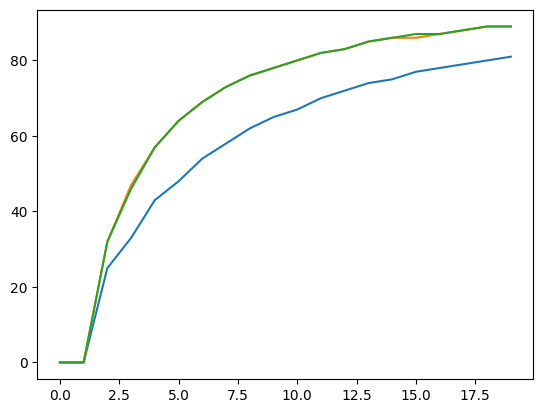

In [17]:
# plot the data
# set the x axis to 'Step' and the y axis to 'Cooperation Rate (1)'
plt.plot(data['Step'], data['Cooperation Rate (1)'], label='Cooperation Rate (1)')
plt.plot(data['Step'], data['Cooperation Rate (2)'], label='Cooperation Rate (2)')
plt.plot(data['Step'], data['Cooperation Rate (3)'], label='Cooperation Rate (3)')
plt.show()

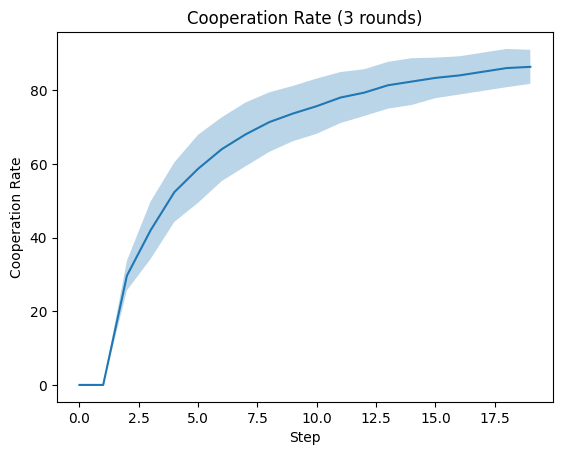

In [18]:
# now plot the average of the cooperation rates of the three columns, and show the standard deviation
data['Cooperation Rate Average'] = data[['Cooperation Rate (1)', 'Cooperation Rate (2)', 'Cooperation Rate (3)']].mean(axis=1)
data['Cooperation Rate Std'] = data[['Cooperation Rate (1)', 'Cooperation Rate (2)', 'Cooperation Rate (3)']].std(axis=1)
# set the x axis to 'Step' and the y axis to 'Cooperation Rate Average'
plt.title('Cooperation Rate (3 rounds)')
plt.xlabel('Step')
plt.ylabel('Cooperation Rate')

plt.plot(data['Step'], data['Cooperation Rate Average'], label='Cooperation Rate Average')
plt.fill_between(data['Step'], data['Cooperation Rate Average'] - data['Cooperation Rate Std'], data['Cooperation Rate Average'] + data['Cooperation Rate Std'], alpha=0.3)
plt.savefig(f'figs/Cooperation_Rate_Average_{file_name.split("_")[1]}.png')
plt.show()

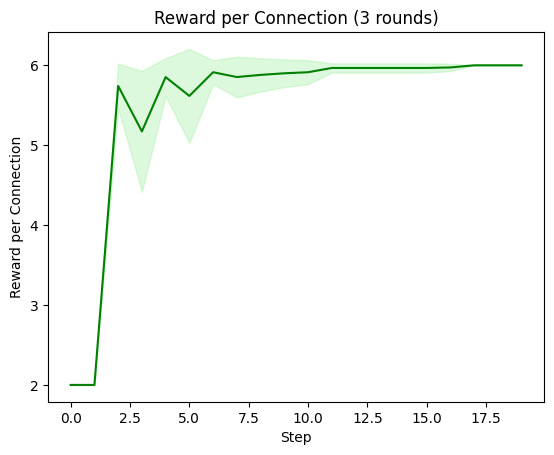

In [24]:
# now divide each column name Total Reward (i) by #Connection (i) to get the reward per connection
data['Reward per Connection (1)'] = data['Total Reward (1)'] / data['#Connections (1)']
data['Reward per Connection (2)'] = data['Total Reward (2)'] / data['#Connections (2)']
data['Reward per Connection (3)'] = data['Total Reward (3)'] / data['#Connections (3)']

# now plot the average of the average rewards per connection of the three columns, and show the standard deviation
data['Reward per Connection Average'] = data[['Reward per Connection (1)', 'Reward per Connection (2)', 'Reward per Connection (3)']].mean(axis=1)
data['Reward per Connection Std'] = data[['Reward per Connection (1)', 'Reward per Connection (2)', 'Reward per Connection (3)']].std(axis=1)

# set the x axis to 'Step' and the y axis to 'Average Reward per Connection Average'
plt.title('Reward per Connection (3 rounds)')
plt.xlabel('Step')
plt.ylabel('Reward per Connection')

plt.plot(data['Step'], data['Reward per Connection Average'], label='Reward per Connection Average', color='green')
plt.fill_between(data['Step'], data['Reward per Connection Average'] - data['Reward per Connection Std'], data['Reward per Connection Average'] + data['Reward per Connection Std'], color='lightgreen', alpha=0.3)
plt.savefig(f'figs/Reward_per_Connection_Average_{file_name.split("_")[1]}.png')
plt.show()

/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_27363/3517207147.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[col + ' per step'].iloc[0] = data[col].iloc[0]
/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_2

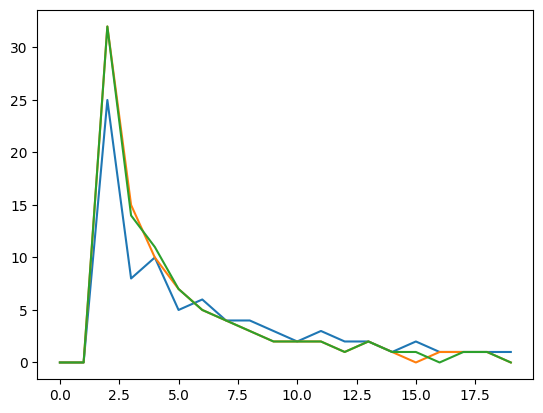

In [25]:
# create a function to get the absolute cooperation rate per step from the aggregated data
def get_absolute_cooperation_rate(data):
    # data['Cooperation Rate (1)'] is the aggregated cooperation rate of all agents
    # create a new column 'Cooperation Rate (1) per step' that contains the cooperation rate per step
    # you have (c1/(c1+d1)) and ((c1+c2)/(c1+d1+c2+d2)). Subtract the first from the second to get the cooperation rate of the second step
    cols = data.columns[data.columns.str.contains('Cooperation Rate')]
    for col in cols:
        data[col + ' per step'] = data[col].diff()
        # set the first value to the first value of the column
        data[col + ' per step'].iloc[0] = data[col].iloc[0]
    return data

# get the absolute cooperation rate per step
data = get_absolute_cooperation_rate(data)

# plot the absolute cooperation rate per step
plt.plot(data['Step'], data['Cooperation Rate (1) per step'], label='Cooperation Rate (1) per step')
plt.plot(data['Step'], data['Cooperation Rate (2) per step'], label='Cooperation Rate (2) per step')
plt.plot(data['Step'], data['Cooperation Rate (3) per step'], label='Cooperation Rate (3) per step')
plt.show()